In [22]:
import torch
from PIL import Image
import os, json, random
import matplotlib.pyplot as plt
import numpy as np
import gc

from tqdm import tqdm
from safetensors.torch import load_file

from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, LMSDiscreteScheduler

from trainscripts.textsliders.lora import (
    LoRANetwork,
    DEFAULT_TARGET_REPLACE,
    UNET_TARGET_REPLACE_MODULE_CONV
)

def flush():
    torch.cuda.empty_cache()
    gc.collect()

@torch.no_grad()
def pil_to_latents(pil_img, vae, device, weight_dtype, height=512, width=512):
    """
    PIL -> VAE latents (SD1.x scaling, latents in model space)
    """
    img = pil_img.convert("RGB").resize((width, height), Image.BICUBIC)
    img = np.array(img).astype(np.float32) / 255.0
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)  # [1,3,H,W]
    img = img * 2.0 - 1.0
    img = img.to(device=device, dtype=weight_dtype)

    latent_dist = vae.encode(img).latent_dist
    latents = latent_dist.sample()
    latents = latents * 0.18215
    return latents

@torch.no_grad()
def latents_to_pil(latents, vae):
    """
    latents -> PIL (SD1.x scaling)
    """
    latents = latents / 0.18215
    image = vae.decode(latents).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
    image = (image * 255).round().astype("uint8")[0]
    return Image.fromarray(image)

def load_lora_state(path: str):
    if path.endswith(".safetensors"):
        sd = load_file(path, device="cpu")
    else:
        sd = torch.load(path, map_location="cpu")
    if isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]
    return sd


In [23]:
# ---------- basic config ----------
pretrained_model_name_or_path = "CompVis/stable-diffusion-v1-4"
revision = None

device = "cuda:3"
weight_dtype = torch.float16

height = 512
width  = 512

ddim_steps = 50
guidance_scale = 7.5
batch_size = 1

# NOTE:  LMS scheduler
noise_scheduler = LMSDiscreteScheduler(
    beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000
)

# ---------- load models ----------
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name_or_path, subfolder="tokenizer", revision=revision)
text_encoder = CLIPTextModel.from_pretrained(pretrained_model_name_or_path, subfolder="text_encoder", revision=revision)
vae = AutoencoderKL.from_pretrained(pretrained_model_name_or_path, subfolder="vae", revision=revision)

text_encoder.requires_grad_(False)
vae.requires_grad_(False)

text_encoder.to(device, dtype=weight_dtype)
vae.to(device, dtype=weight_dtype)

flush()
print("Loaded tokenizer/text_encoder/vae.")


Loaded tokenizer/text_encoder/vae.


In [24]:
# path to your LoRA model(s)
lora_weights = [
    "models/Florence_alpha1.0_rank16_noxattn/Florence_alpha1.0_rank16_noxattn_last.safetensors",
]

# prompt 
prompts = [
    "a high-resolution satellite image, overhead view of a coastal urban area, residential buildings, roads, vegetation, clear weather, natural colors",
]

# slider scales to test
scales = [0, 0.5, 1, 1.5, 2, 2.5, 3]

# img2img strengths to test (控制贴近原图程度)
# 0.25~0.45: 更保结构; 0.6+: 变化更大
strengths = [0.25, 0.35, 0.45]

# 输入图片路径：换成你的遥感图
init_image_path = "datasets/Disaster_Recognition_RemoteSense_EN_CN_JA_hub/test/images/hurricane-florence_00000046_pre_disaster.png"

# 如果你想批量测试多张输入图，也可以给一个 list：
# init_image_paths = glob.glob("your_folder/*.png")


In [25]:
@torch.no_grad()
def run_one(
    prompt: str,
    lora_weight_path: str,
    scale: float,
    init_pil: Image.Image,
    strength: float,
    seed: int,
):
    if "full" in lora_weight_path:
        train_method = "full"
    elif "noxattn" in lora_weight_path:
        train_method = "noxattn"
    else:
        train_method = "noxattn"

    network_type = "c3lier"
    if train_method == "xattn":
        network_type = "lierla"

    modules = DEFAULT_TARGET_REPLACE
    if network_type == "c3lier":
        modules += UNET_TARGET_REPLACE_MODULE_CONV

    unet = UNet2DConditionModel.from_pretrained(
        pretrained_model_name_or_path, subfolder="unet", revision=revision
    )
    unet.requires_grad_(False)
    unet.to(device, dtype=weight_dtype)

    rank = 16
    alpha = 1.0
    if "rank8" in lora_weight_path:
        rank = 8
    if "alpha1" in lora_weight_path:
        alpha = 1.0

    network = LoRANetwork(
        unet,
        rank=rank,
        multiplier=1.0,
        alpha=alpha,
        train_method=train_method,
    ).to(device, dtype=weight_dtype)

    sd = load_lora_state(lora_weight_path)
    network.load_state_dict(sd, strict=False)

    # ---- text embeddings (CFG) ----
    text_input = tokenizer(
        prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    text_embeddings = text_encoder(text_input.input_ids.to(device))[0]

    uncond_input = tokenizer(
        [""] * batch_size,
        padding="max_length",
        max_length=text_input.input_ids.shape[-1],
        return_tensors="pt",
    )
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(device))[0]
    text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

    # ---- img2img init latents ----
    noise_scheduler.set_timesteps(ddim_steps)
    timesteps_all = list(noise_scheduler.timesteps)

    strength = float(strength)
    strength = min(max(strength, 0.0), 0.999)

    t_start = int(len(timesteps_all) * strength)
    t_start = min(max(t_start, 0), len(timesteps_all) - 1)

    init_latents = pil_to_latents(init_pil, vae, device, weight_dtype, height=height, width=width)
    init_latents = init_latents.to(device=device, dtype=weight_dtype)

    # ---- noise (older torch compatible) ----
    torch.manual_seed(seed)
    noise = torch.randn(
        init_latents.shape,
        device=init_latents.device,
        dtype=init_latents.dtype,
    )

    # ---- FIX: make t0 a 1D tensor (batch,) for LMSDiscreteScheduler.add_noise ----
    t0 = timesteps_all[t_start]
    if isinstance(t0, torch.Tensor):
        if t0.dim() == 0:
            t0 = t0[None]
        t0 = t0.to(device)
    else:
        t0 = torch.tensor([t0], device=device)
    t0 = t0.repeat(batch_size)  # [batch_size]

    latents = noise_scheduler.add_noise(init_latents, noise, t0)
    latents = latents.to(device=device, dtype=weight_dtype)

    # denoise remaining steps
    timesteps = timesteps_all[t_start:]
    switch_i = int(len(timesteps) * 0.4)

    for i, t in enumerate(timesteps):
        network.set_lora_slider(scale=0.0 if i < switch_i else float(scale))

        latent_model_input = torch.cat([latents] * 2)
        latent_model_input = noise_scheduler.scale_model_input(latent_model_input, timestep=t)

        with network:
            noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

    out_pil = latents_to_pil(latents, vae)

    del network, unet
    flush()
    return out_pil


Prompt: a high-resolution satellite image, overhead view of a coastal urban area, residential buildings, roads, vegetation, clear weather, natural colors
LoRA: models/Florence_alpha1.0_rank16_noxattn/Florence_alpha1.0_rank16_noxattn_last.safetensors
Seed: 3160
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-Net: 150 modules.
create LoRA for U-N

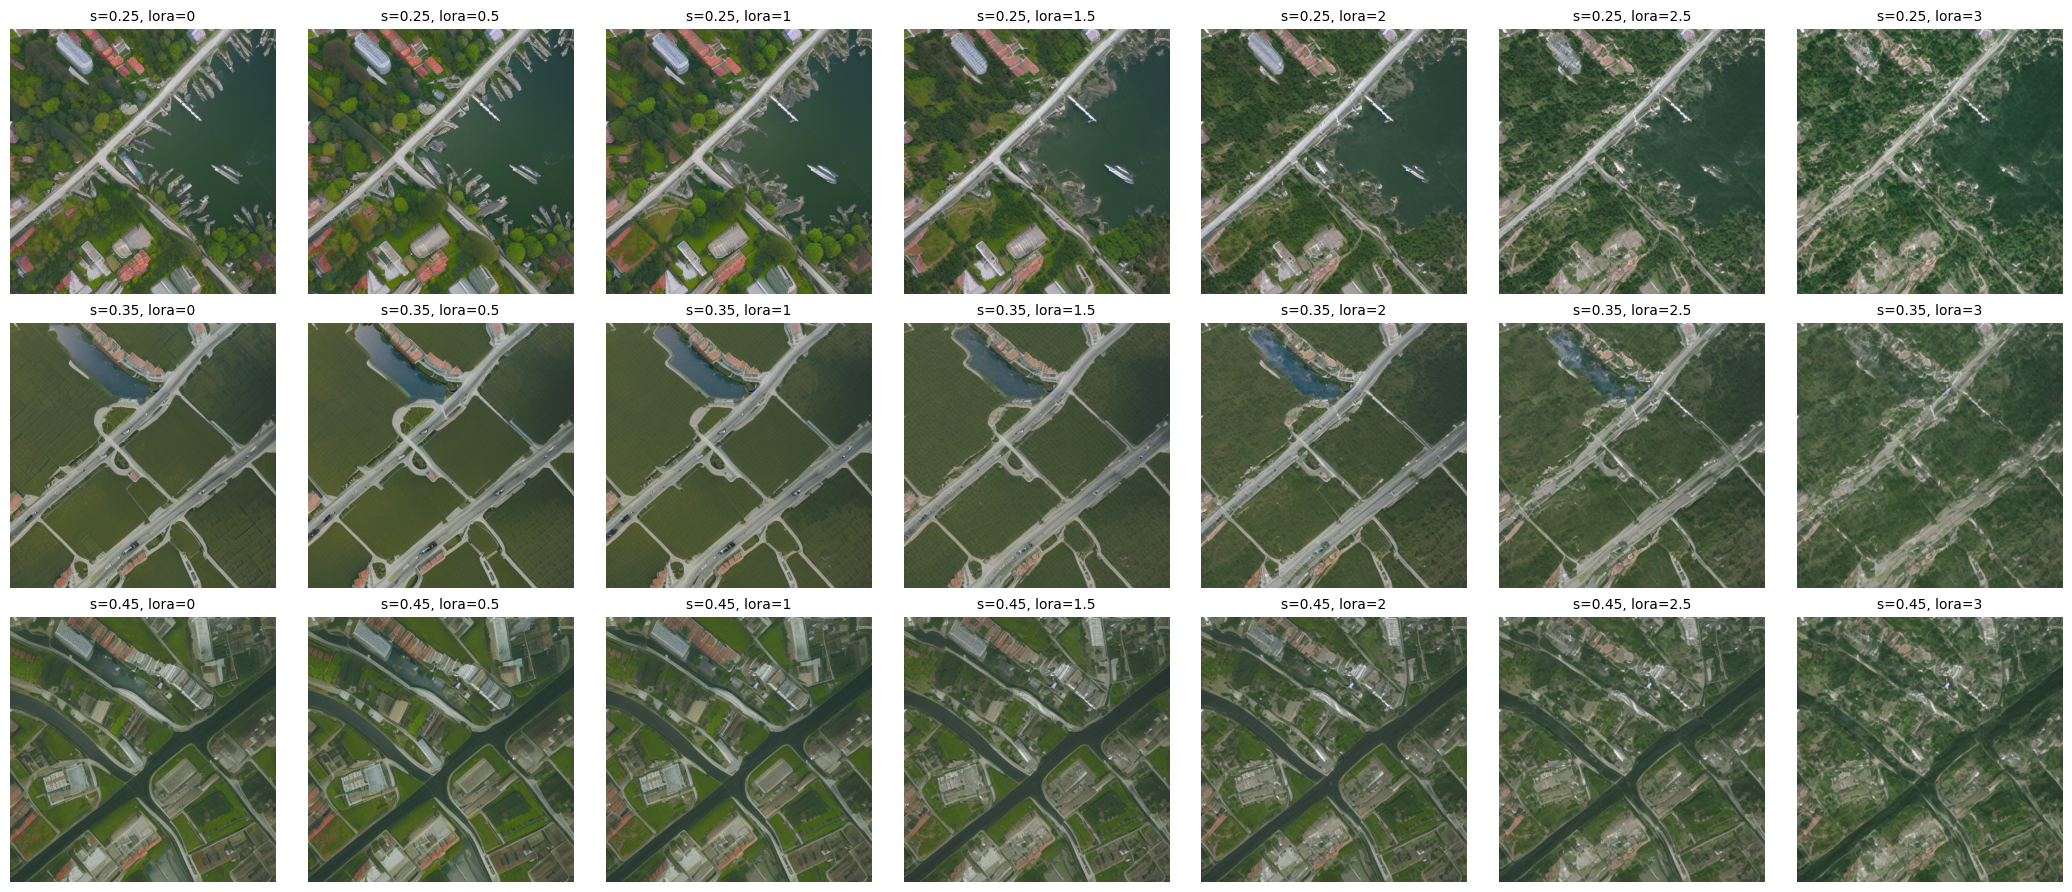

In [26]:
# load init image once
assert os.path.exists(init_image_path), f"init_image_path not found: {init_image_path}"
init_pil = Image.open(init_image_path)

for prompt in prompts:
    for lora_weight in lora_weights:
        # 固定一个 seed
        seed = random.randint(0, 5000)
        # seed = 0
        print("Prompt:", prompt)
        print("LoRA:", lora_weight)
        print("Seed:", seed)

        # grid: rows=strengths, cols=scales
        fig, axes = plt.subplots(len(strengths), len(scales), figsize=(3*len(scales), 3*len(strengths)))
        if len(strengths) == 1:
            axes = np.expand_dims(axes, axis=0)
        if len(scales) == 1:
            axes = np.expand_dims(axes, axis=1)

        for r, strength in enumerate(strengths):
            for c, scale in enumerate(scales):
                out = run_one(
                    prompt=prompt,
                    lora_weight_path=lora_weight,
                    scale=scale,
                    init_pil=init_pil,
                    strength=strength,
                    seed=seed
                )
                ax = axes[r, c]
                ax.imshow(out)
                ax.axis("off")
                ax.set_title(f"s={strength}, lora={scale}", fontsize=10)

        plt.tight_layout()
        plt.show()
